# 👋 Hola Mundo - Machine Learning + MLflow

Notebook introductorio: clasificación simple usando un dataset de `scikit-learn`, con tracking de experimentos en **MLflow**.

**Dataset:** Iris (clasificación de especies de flores)  
**Modelo:** Random Forest Classifier  
**Contenido:**
1. Carga de datos
2. Exploración rápida
3. Train/test split
4. Configuración de MLflow
5. Entrenamiento del modelo (dentro de un run de MLflow)
6. Métricas de evaluación (logueadas en MLflow)
7. Matriz de confusión (logueada como artefacto)
8. Importancia de características (logueada como artefacto)
9. Registro del modelo en el Model Registry

## 1. Importar librerías

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.sklearn

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

print("Librerías importadas correctamente ✅")

c:\Users\GERA\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías importadas correctamente ✅


## 2. Cargar el dataset

Usamos el clásico dataset **Iris**, incluido en `sklearn.datasets`. Contiene 150 muestras de flores con 4 características (largo/ancho de pétalo y sépalo) y 3 clases (especies).

In [2]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")
target_names = iris.target_names

print(f"Forma de X: {X.shape}")
print(f"Clases: {list(target_names)}")
X.head()

Forma de X: (150, 4)
Clases: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 3. Exploración rápida

Distribución de clases:
target
0    50
1    50
2    50
Name: count, dtype: int64


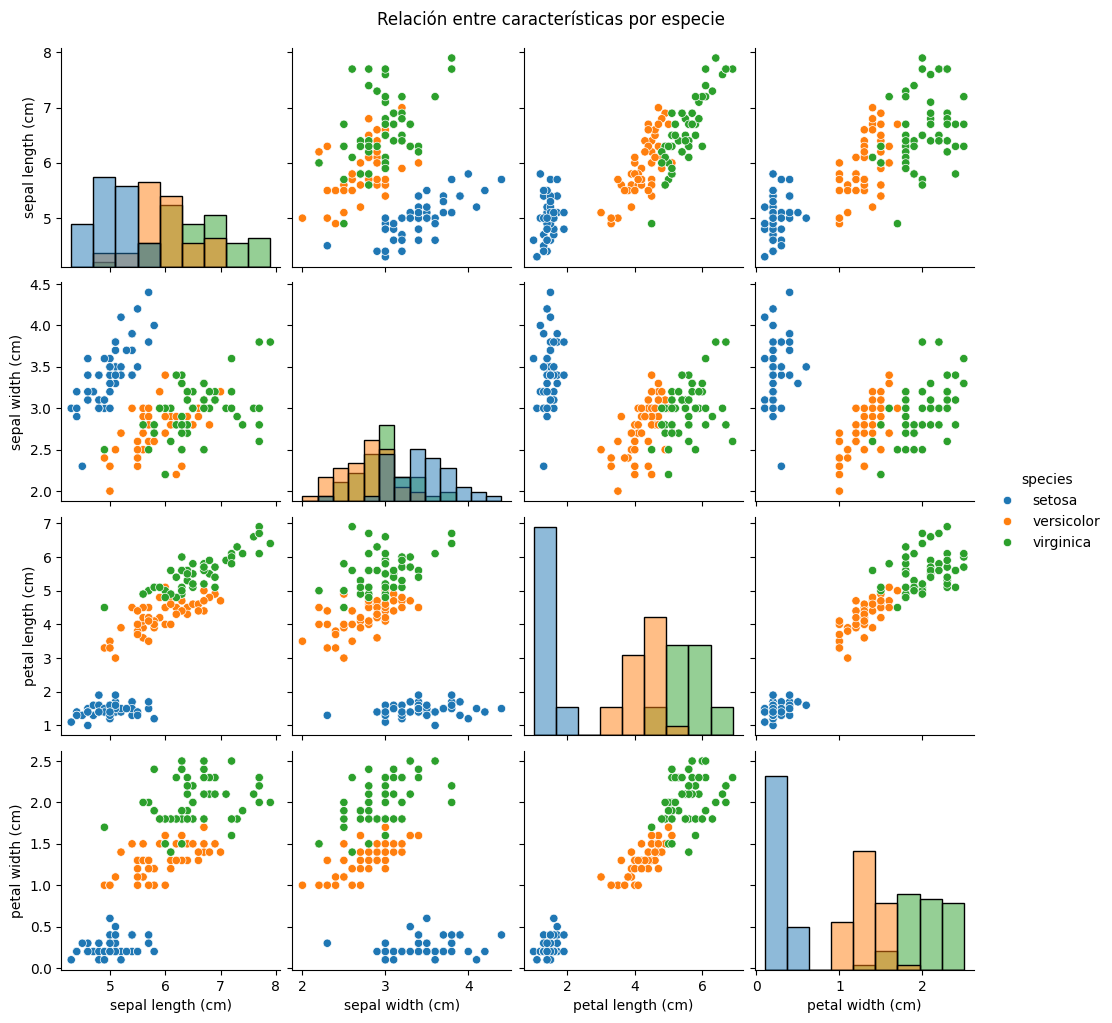

In [3]:
print("Distribución de clases:")
print(y.value_counts().sort_index())

df_plot = X.copy()
df_plot["species"] = y.map(dict(enumerate(target_names)))

pairplot_fig = sns.pairplot(df_plot, hue="species", diag_kind="hist")
pairplot_fig.fig.suptitle("Relación entre características por especie", y=1.02)
plt.show()

## 4. Dividir en entrenamiento y prueba

In [4]:
TEST_SIZE = 0.2
RANDOM_STATE = 42
N_ESTIMATORS = 100

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")

Entrenamiento: 120 muestras
Prueba: 30 muestras


## 5. Configurar MLflow

Apunta al servidor de tracking del `docker-compose` (servicio `mlflow`, puerto `5000`). Si el notebook corre **dentro** del contenedor de `code-server`, la variable de entorno `MLFLOW_TRACKING_URI` ya está inyectada; si corres localmente fuera de Docker, ajusta la URL al host/puerto expuesto.

In [5]:
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI")
assert MLFLOW_TRACKING_URI, "Falta MLFLOW_TRACKING_URI en el .env del proyecto"

EXPERIMENT_NAME = "clasificacion-iris"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experimento: {EXPERIMENT_NAME}")

2026/09/27 11:57:20 INFO mlflow.tracking.fluent: Experiment with name 'clasificacion-iris' does not exist. Creating a new experiment.


Tracking URI: http://208.68.37.250:5000/
Experimento: clasificacion-iris


## 6. Entrenar el modelo dentro de un run de MLflow

Todo lo que ocurre dentro del bloque `with mlflow.start_run():` queda registrado como una corrida (run): parámetros, métricas, artefactos y el modelo entrenado.

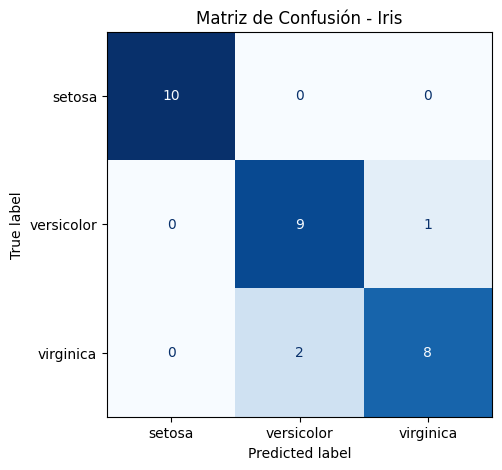

C:\Users\GERA\AppData\Local\Temp\ipykernel_7908\4254442751.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis", ax=ax_imp)


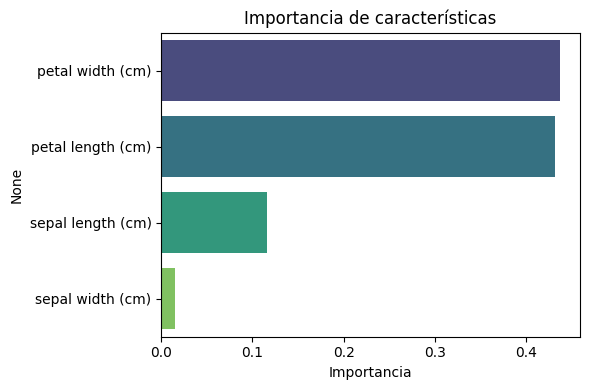

2026/09/27 11:59:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run random-forest-baseline at: http://208.68.37.250:5000/#/experiments/2/runs/865c4a801155467dbb9bb1538c9e7f68
🧪 View experiment at: http://208.68.37.250:5000/#/experiments/2


MlflowException: API request to endpoint /api/2.0/mlflow/logged-models failed with error code 404 != 200. Response body: '<!doctype html>
<html lang=en>
<title>404 Not Found</title>
<h1>Not Found</h1>
<p>The requested URL was not found on the server. If you entered the URL manually please check your spelling and try again.</p>
'

In [7]:
with mlflow.start_run(run_name="random-forest-baseline") as run:

    # --- Parámetros ---
    mlflow.log_params({
        "model_type": "RandomForestClassifier",
        "n_estimators": N_ESTIMATORS,
        "test_size": TEST_SIZE,
        "random_state": RANDOM_STATE,
    })

    # --- Entrenamiento ---
    model = RandomForestClassifier(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)

    # --- Predicción y métricas ---
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    mlflow.log_metrics({
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
    })

    # --- Matriz de confusión (figura -> artefacto) ---
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax_cm, cmap="Blues", colorbar=False)
    plt.title("Matriz de Confusión - Iris")
    mlflow.log_figure(fig_cm, "confusion_matrix.png")
    plt.show()

    # --- Importancia de características (figura -> artefacto) ---
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    fig_imp, ax_imp = plt.subplots(figsize=(6, 4))
    sns.barplot(x=importances.values, y=importances.index, palette="viridis", ax=ax_imp)
    ax_imp.set_title("Importancia de características")
    ax_imp.set_xlabel("Importancia")
    plt.tight_layout()
    mlflow.log_figure(fig_imp, "feature_importance.png")
    plt.show()

    # --- Reporte de clasificación completo (texto -> artefacto) ---
    report_text = classification_report(y_test, y_pred, target_names=target_names)
    mlflow.log_text(report_text, "classification_report.txt")

    # --- Modelo entrenado -> artefacto versionado ---
    mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="model",
        input_example=X_train.iloc[:5],
    )

    run_id = run.info.run_id

    print(f"Run ID: {run_id}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("\nReporte de clasificación completo:\n")
    print(report_text)

## 7. Ver el run en la UI de MLflow

Abre la interfaz web de MLflow (por defecto `http://<tu-servidor>:5000`) y busca el experimento **`clasificacion-iris`**. Ahí verás el run recién creado con:
- Parámetros (`n_estimators`, `test_size`, `random_state`)
- Métricas (`accuracy`, `precision_macro`, `recall_macro`, `f1_macro`)
- Artefactos (`confusion_matrix.png`, `feature_importance.png`, `classification_report.txt`, carpeta `model/`)

También puedes recuperar el `run_id` directamente desde este notebook:

In [ ]:
print(f"Run registrado con ID: {run_id}")
print(f"URL del experimento: {MLFLOW_TRACKING_URI}/#/experiments")

## 8. (Opcional) Registrar el modelo en el Model Registry

Si esta corrida cumple con el desempeño esperado, puedes promoverla a una versión con nombre dentro del **Model Registry** de MLflow. Esto permite manejar versiones (`v1`, `v2`, ...) y etiquetas de ciclo de vida (`Staging`, `Production`).

In [ ]:
REGISTERED_MODEL_NAME = "iris-random-forest"

model_uri = f"runs:/{run_id}/model"

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name=REGISTERED_MODEL_NAME,
)

print(f"Modelo registrado: {registered_model.name}, versión {registered_model.version}")

## ✅ Resumen

Este notebook cubrió el flujo básico de un proyecto de ML integrado con MLOps:

1. Carga de datos (`sklearn.datasets`)
2. Exploración visual
3. División train/test
4. Entrenamiento (`RandomForestClassifier`) dentro de un **run de MLflow**
5. Métricas logueadas (`accuracy`, `precision`, `recall`, `f1`)
6. Artefactos logueados (matriz de confusión, importancia de features, reporte de clasificación, modelo serializado)
7. Registro del modelo en el **Model Registry**

Próximos pasos posibles: comparar múltiples runs en la UI de MLflow, hacer *hyperparameter tuning* con `GridSearchCV` logueando cada combinación como un run distinto, o promover una versión del modelo a `Production` y servirla con `mlflow models serve`. 🚀